## 🔍 Example: Sub-pixel Image Registration using DFT

### This example demonstrates how to perform **sub-pixel image rigid registration** using two implementations of the Discrete Fourier Transform (DFT) registrator:

1. NumPy version   `Torch_DFT_Registrator`
2. PyTorch version `Torch_DFT_Registrator`


> 📌 *Note:* Both implementations also include a function to shift images at sub-pixel precision.


<span style="color:Lightgreen"><strong>When using this code, please cite:</strong></span>

*   Jose J. Rico-Jimenez, et al., "Real-time OCT image denoising using a self-fusion neural network," 
   Biomed. Opt. Express 13, 1398-1409 (2022)


In [1]:
import sys, os
import numpy as np
from skimage import data
import matplotlib.pyplot as plt

# Add parent directory to the Python path
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)

# Import the DFT registrators form the py_tools package
from impro_tools.DFT_registration import  Torch_DFT_Registrator, Numpy_DFT_Registrator

* Define the registrators and shift the image using both approaches

In [2]:
# Define the image registrators
torch_reg = Torch_DFT_Registrator(img_size=(512, 512), usfac=20, device='cpu', ) # 'cuda' for GPU
numpy_reg = Numpy_DFT_Registrator(img_size=(512, 512), usfac=20)

In [46]:
# 1) SHIFT THE IMAGE IN BOTH AXIS
# Load the image
img = data.camera()
print("image shape:", img.shape, img.dtype)

# Define the shift to be applied
shift = (130.3, -20.8)

image shape: (512, 512) uint8


* Shift the image using both registrators

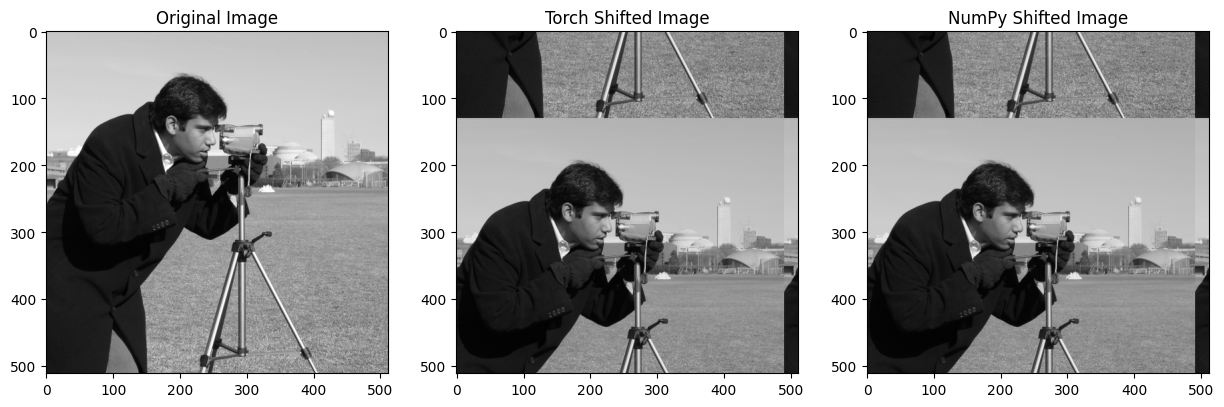

In [4]:
# 2) SHIFT THE IMAGE USING BOTH REGISTRATORS
torch_img_shifted = torch_reg.img_shift(image=img, shift=shift)
numpy_img_shifted = numpy_reg.img_shift(image=img, shift=shift)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(132)
plt.imshow(torch_img_shifted, cmap='gray')
plt.title("Torch Shifted Image")
plt.subplot(133)
plt.imshow(numpy_img_shifted, cmap='gray')
plt.title("NumPy Shifted Image")
plt.show()

* Register the image using Pytorch

Pytorch | Found shift (y, x): [-130.3000030517578, 20.799999237060547]


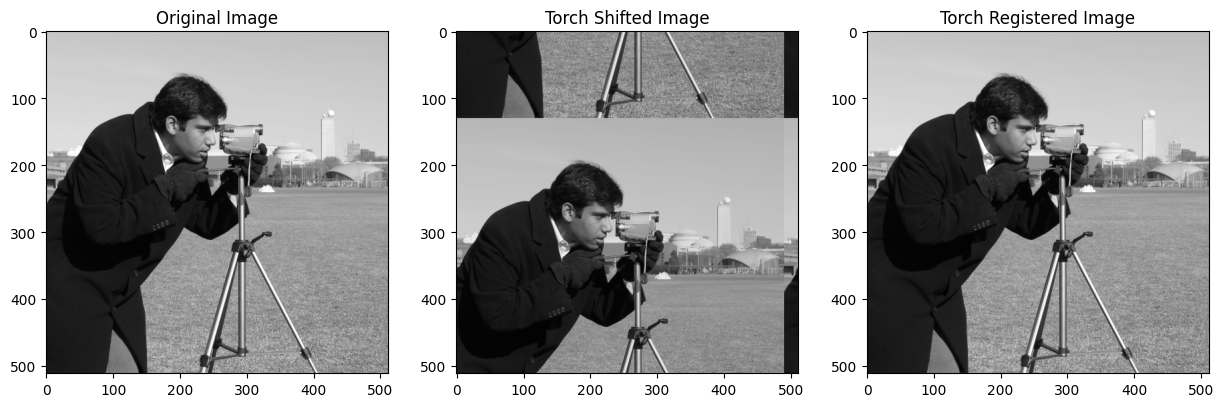

In [5]:
# 3) REGISTER THE SHIFTED IMAGE BACK TO THE ORIGINAL USING PYTORCH REGISTRATOR
torch_reg_shift, torch_img_registered = torch_reg(img, torch_img_shifted)
print("Pytorch | Found shift (y, x):", torch_reg_shift)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(132)
plt.imshow(torch_img_shifted, cmap='gray')
plt.title("Torch Shifted Image")
plt.subplot(133)
plt.imshow(torch_img_registered, cmap='gray')
plt.title("Torch Registered Image")
plt.show()


* Register the image using Numpy

NumPy   | Found shift (y, x): [-130.3, 20.8]


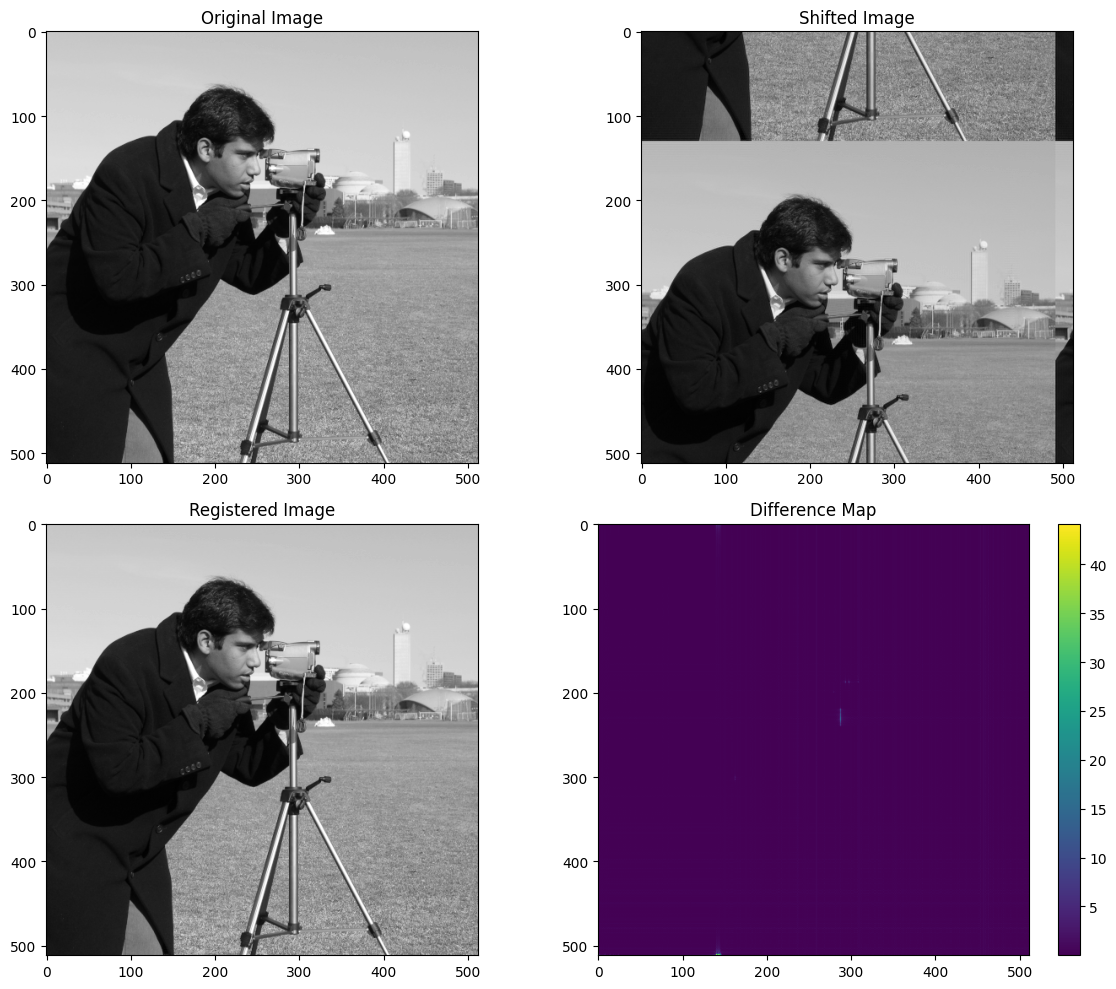

In [6]:
# 4) REGISTER THE SHIFTED IMAGE BACK TO THE ORIGINAL USING NUMPY REGISTRATOR
numpy_reg_shift, numpy_img_registered = numpy_reg(img, numpy_img_shifted)
print("NumPy   | Found shift (y, x):", numpy_reg_shift)

plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(222)
plt.imshow(numpy_img_shifted, cmap='gray')
plt.title("Shifted Image")
plt.subplot(223)
plt.imshow(numpy_img_registered, cmap='gray')
plt.title("Registered Image")
plt.subplot(224)
plt.imshow(np.abs(img-numpy_img_registered))
plt.colorbar()
plt.title("Difference Map")
plt.tight_layout()
plt.show()


# Image registration with padding

1) Same size

NumPy   | Found shift (y, x): [300.0, 120.0]


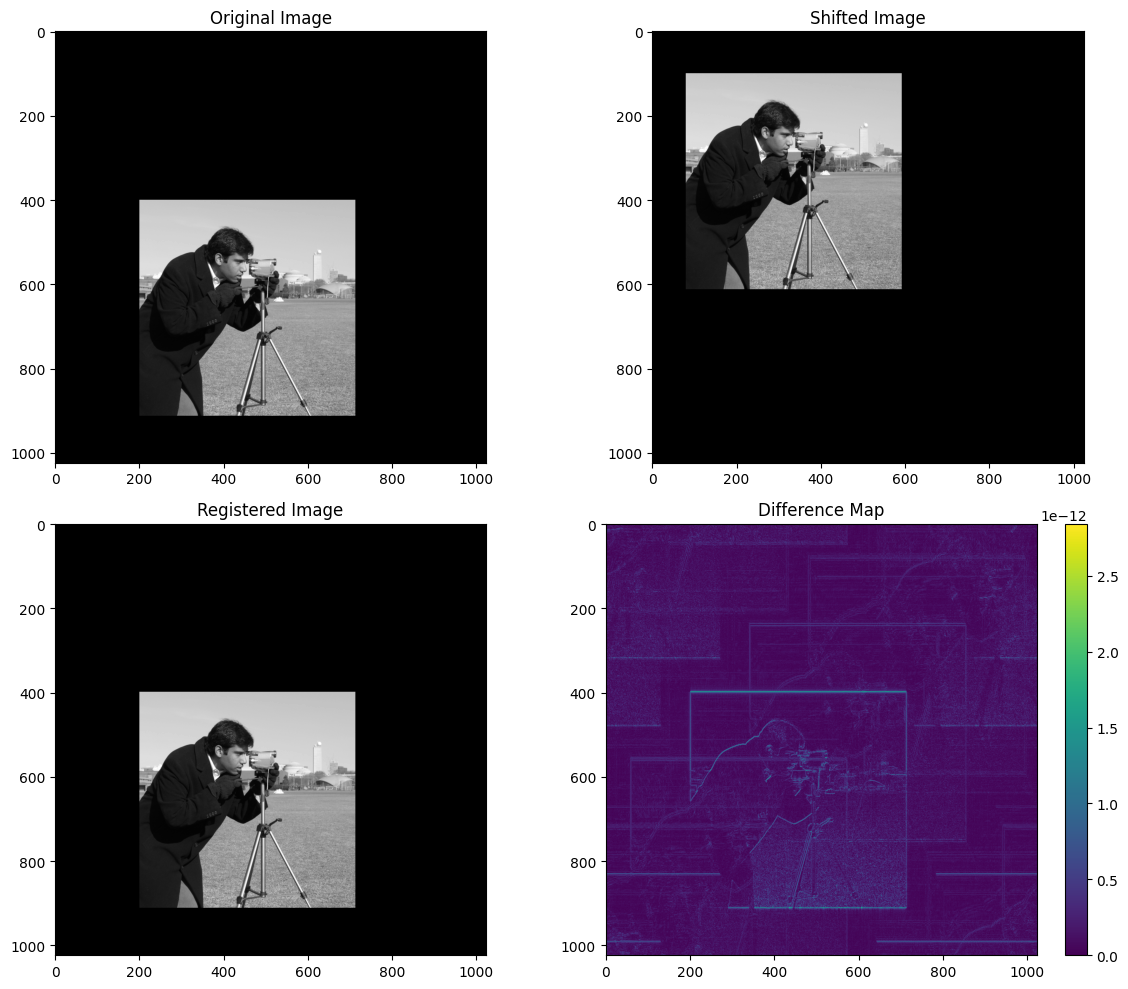

In [7]:
# Define the DFT registration with the padding size
pad_size = (1024, 1024)
numpy_reg = Numpy_DFT_Registrator(img_size=pad_size, usfac=20)

# Add the camera image to the padded (zeros) image in the initial position
h, w = img.shape
img_pos = (400, 200)
img_pad = np.zeros(pad_size)
img_pad[img_pos[0]:img_pos[0]+w, img_pos[1]:img_pos[1]+h] = img

# Add the camera image to a new padded image in a different position (shifted0)
img_shifted_pos = (100, 80)
img_shifted_pad = np.zeros(pad_size)
img_shifted_pad[img_shifted_pos[0]:img_shifted_pos[0]+w, img_shifted_pos[1]:img_shifted_pos[1]+h] = img

# Register the image
numpy_reg_shift, numpy_img_registered = numpy_reg(img_pad, img_shifted_pad)
print("NumPy   | Found shift (y, x):", numpy_reg_shift)

plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(img_pad, cmap='gray')
plt.title("Original Image")
plt.subplot(222)
plt.imshow(img_shifted_pad, cmap='gray')
plt.title("Shifted Image")
plt.subplot(223)
plt.imshow(numpy_img_registered, cmap='gray')
plt.title("Registered Image")
plt.subplot(224)
plt.imshow(np.abs(img_pad-numpy_img_registered))
plt.colorbar()
plt.title("Difference Map")
plt.tight_layout()
plt.show()


2) Different size

NumPy   | Found shift (y, x): [300.2, -288.45]


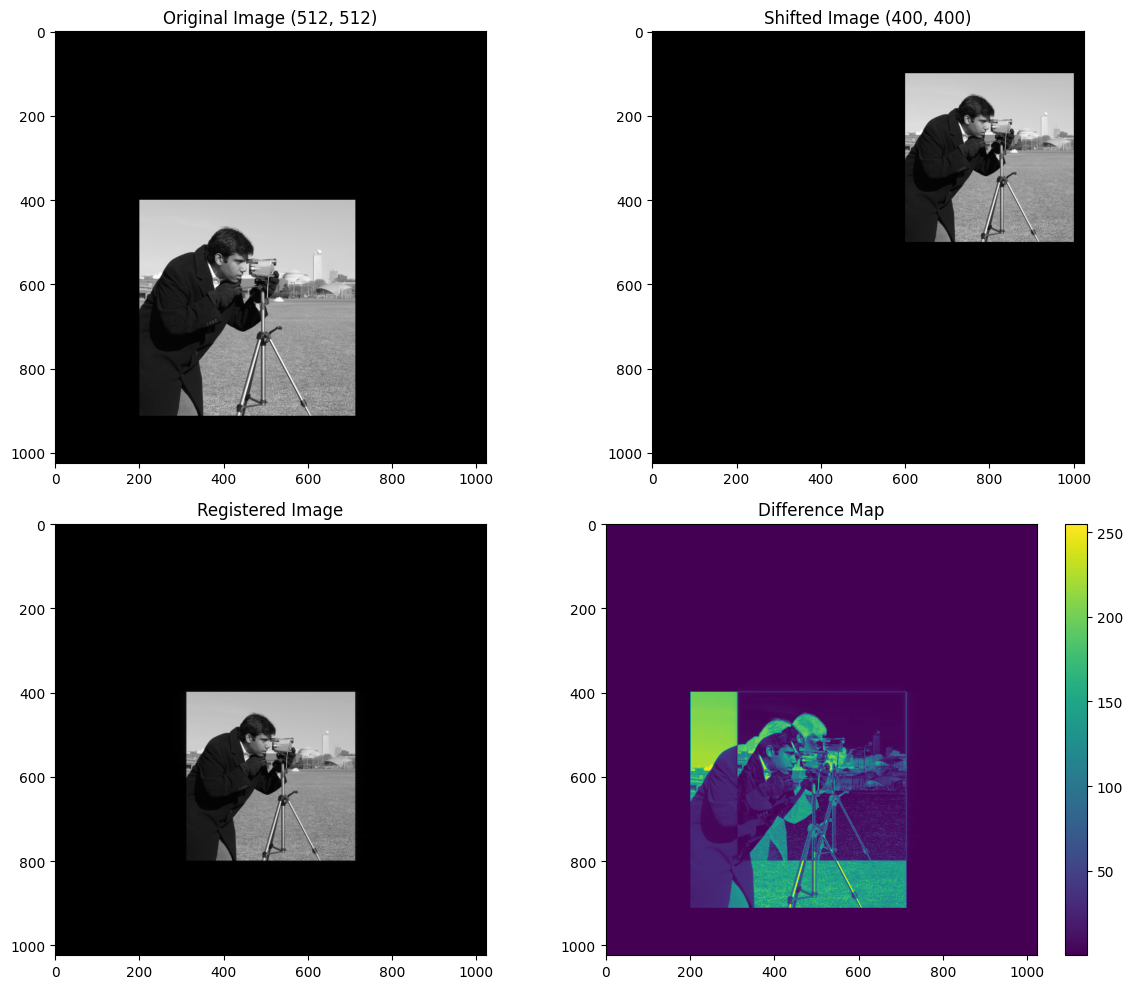

In [8]:
import cv2
# Define the DFT registration with the padding size
pad_size = (1024, 1024)
numpy_reg = Numpy_DFT_Registrator(img_size=pad_size, usfac=20)

# Add the camera image to the padded (zeros) image in the initial position
h, w = img.shape
img_pos = (400, 200)
img_pad = np.zeros(pad_size)
img_pad[img_pos[0]:img_pos[0]+w, img_pos[1]:img_pos[1]+h] = img

# Add the camera image to a new padded image in a different position (shifted0)
new_size = (400, 400)
small_img = cv2.resize(img, new_size)
h, w = small_img.shape
img_shifted_pos = (100, 600)
img_shifted_pad = np.zeros(pad_size)
img_shifted_pad[img_shifted_pos[0]:img_shifted_pos[0]+w, img_shifted_pos[1]:img_shifted_pos[1]+h] = small_img

# Register the image
numpy_reg_shift, numpy_img_registered = numpy_reg(img_pad, img_shifted_pad)
print("NumPy   | Found shift (y, x):", numpy_reg_shift)

plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(img_pad, cmap='gray')
plt.title("Original Image (512, 512)")
plt.subplot(222)
plt.imshow(img_shifted_pad, cmap='gray')
plt.title("Shifted Image (400, 400)")
plt.subplot(223)
plt.imshow(numpy_img_registered, cmap='gray')
plt.title("Registered Image")
plt.subplot(224)
plt.imshow(np.abs(img_pad-numpy_img_registered))
plt.colorbar()
plt.title("Difference Map")
plt.tight_layout()
plt.show()